## Chapitre 2: Statistiques Et Analyse Exploratoire des données EDA

### Table des Contenus
1. [Introduction](#introduction)
2. [Data Import](#dataimport)
    1. [Description du Dataset](#Datasetdescription1)
    2. [Experimentation de la Distribution Normal ](#nde)
3. [Analyse Exploratoire des données EDA (Data Exploration)](#eda)
    1. [Données manquantes](#missing)
    2. [Analyse des Outlier](#outlier)
    3. [Analyse Graphique](#outliergraph)
    4. [Corrélation](#correlation)
4. [Distribution Binomial, Bernaoulli, Poisson](#distribution)
5. [Test Statistiques ](#test)
6. [Données des séries temporelles](#ts)

### On importe toutes les bibliothèques nécessaires <a name="introduction"></a>

In [1]:
#Bibliothèque d'analyse de données 
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

### Chargez vos données d'entrée <a name="dataimport"></a>

In [2]:
HMDA_IL_2020 = pd.read_csv('Input Data/state_IL_lei_B4TYDEB6GKMZO031MB27.csv')
HMDA_IL_2020.head(3)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason-2,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2020,B4TYDEB6GKMZO031MB27,99999,IL,17001,17001001100,NC,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,8076,9.09,65800,117,2203,2796,38
1,2020,B4TYDEB6GKMZO031MB27,99999,IL,17001,17001001001,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3737,3.64,65800,100,1198,1575,68
2,2020,B4TYDEB6GKMZO031MB27,99999,IL,17001,17001001100,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,8076,9.09,65800,117,2203,2796,38


In [3]:
#Nous vérifions d'abord le nombre total d'enregistrements dans les données 
print ( "Nombre d'enregistrements :" ,  HMDA_IL_2020 . shape [ 0 ]) 
#Nombre total de variables dans les données 
print ( "Nombre de variables :" ,  HMDA_IL_2020 . shape [ 1 ])

Nombre d'enregistrements : 10636
Nombre de variables : 99


### Ligne normale pour l'expérience de distribution normale <a name="nde"></a>

In [4]:
#calculer la moyenne à l'aide de la formule 
echantillon  =  [ 1 , 2 , 3 , 4 , 4 , 5 , 6 ] 
Moyenne =  sum( echantillon ) / len ( echantillon ) 
Moyenne

3.5714285714285716

In [5]:
#calculer en utilisant la fonction intégrée 
echantillon  =  [ 1 , 2 , 3 , 4 , 4 , 5 , 6 ] 
import statistics
statistics.mean(echantillon)
#3.5714285714285716
statistics.median(echantillon)
#resultat: 4
statistics.mode(echantillon)
#resultat: 4

4

In [6]:
#variance
print(statistics.variance(echantillon))

2.9523809523809526


In [7]:
#Ecart-type 
statistics.stdev(echantillon)

1.7182493859684491

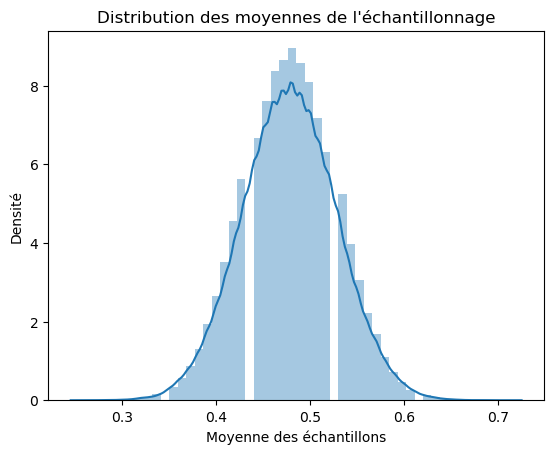

In [8]:
#Distribution binomiale
binom_dist = np.random.binomial(1, 0.5, 1000)

# Liste des moyennes
list_of_means = []
for i in range(100000):
    list_of_means.append(np.random.choice(binom_dist, 100, replace=True).mean())

sns.distplot(list_of_means, kde=True)

# Ajouter un titre et des labels aux axes
plt.title('Distribution des moyennes de l\'échantillonnage')
plt.xlabel('Moyenne des échantillons')
plt.ylabel('Densité')

# Afficher le graphique
plt.show()

ou

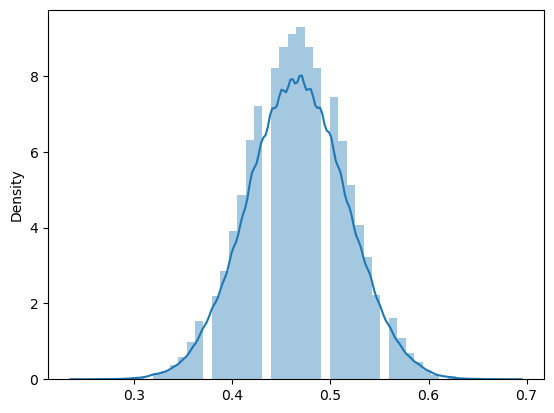

In [9]:
#Distribution binomiale 
binom_dist = np.random.binomial(1, .5, 1000)
list_of_means = []
for i in range(0, 100000):
    list_of_means.append(np.random.choice(binom_dist, 100, replace=True).mean())
fig, ax = plt.subplots()
ax = sns.distplot(list_of_means)

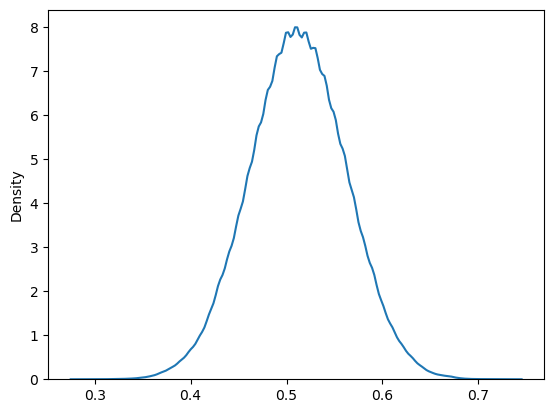

In [10]:
#Distribution Binomial
binom_dist = np.random.binomial(1, .5, 1000)
list_of_means = []
for i in range(0, 100000):
    list_of_means.append(np.random.choice(binom_dist, 100, replace=True).mean())
fig, ax = plt.subplots()
ax = sns.kdeplot(list_of_means)

### Exploration des données EDA <a name="eda"></a>

In [11]:
#Vérifions les valeurs manquantes et le type de données de chaque variable 
HMDA_IL_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10636 entries, 0 to 10635
Data columns (total 99 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   activity_year                             10636 non-null  int64  
 1   lei                                       10636 non-null  object 
 2   derived_msa-md                            10636 non-null  int64  
 3   state_code                                10636 non-null  object 
 4   county_code                               10636 non-null  int64  
 5   census_tract                              10636 non-null  int64  
 6   conforming_loan_limit                     10634 non-null  object 
 7   derived_loan_product_type                 10636 non-null  object 
 8   derived_dwelling_category                 10636 non-null  object 
 9   derived_ethnicity                         10636 non-null  object 
 10  derived_race                      

In [12]:
#Spécifier les numéros de colonne à sélectionner. Dans le dataframe, la colonne commence à l'index = 0 ; voir le résultat de DF.info(). 
#À des fins pédagogiques, nous choisirons quelques (6) variables importantes d'un point de vue métier. 
HMDA_IL = HMDA_IL_2020[['derived_race','derived_sex','action_taken','loan_amount','interest_rate','income']]
print(HMDA_IL_2020.shape)
print(HMDA_IL.shape)

(10636, 99)
(10636, 6)


### Vérifier les valeurs nulles <a name="missing"></a>

In [13]:
HMDA_IL.isnull().sum()

derived_race        0
derived_sex         0
action_taken        0
loan_amount         0
interest_rate    4341
income            212
dtype: int64

In [14]:
#Il manque des valeurs. Nous les imputons à l'aide de méthodes statistiques, comme la moyenne. Par souci de simplicité, nous les remplacerons par 0. 
HMDA_IL= HMDA_IL.fillna(0)

In [15]:
#vérifier les statistiques récapitulatives 
HMDA_IL.describe()

,action_taken,loan_amount,interest_rate,income
count,10636.000000,1.063600e+04,10636.000000,10636.000000
mean,2.209195,2.733725e+05,1.854597,168.576815
std,1.435579,4.026370e+05,1.671854,321.770032
min,1.000000,5.000000e+03,0.000000,-280.000000
25%,1.000000,1.050000e+05,0.000000,61.000000
50%,1.000000,1.750000e+05,2.625000,102.000000
75%,3.000000,3.050000e+05,3.250000,184.000000
max,6.000000,1.650500e+07,15.625000,20143.000000


In [16]:
#let's make variable "action taken" little descriptive
action_codes = {1:'Approved',2:'Approved but not accepted',3:'Denied',4:'Application Withdrawn',5:'File Incomplete',6:'Purchased Loan',7:'Preapproval Denied',8:'Approved but not accepted'}
HMDA_IL["action_taken"] = HMDA_IL["action_taken"].map(action_codes)

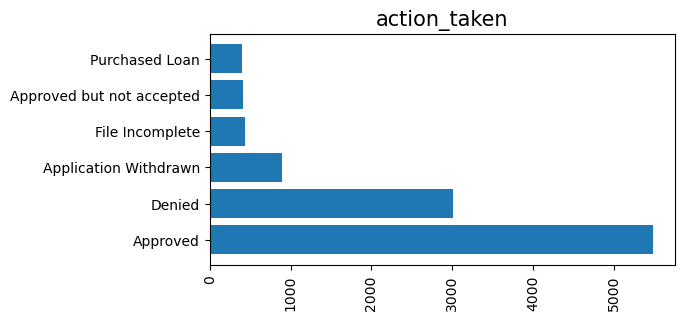

In [17]:
#Visualisez la distribution 
vc =  HMDA_IL.action_taken.value_counts ( dropna = False ) 
plt.figure ( figsize = ( 6 ,  len ( vc . keys ()) / 2 )) 
plt.barh(vc.keys(), vc.values)
plt.title( "action_taken", fontsize = 15 ) 
plt.xticks( rotation = 'vertical',  fontsize = 10 ) 
plt.show()

In [18]:
Approval_vs_Race = pd.crosstab(index=HMDA_IL["derived_race"], columns=HMDA_IL["action_taken"]) 
Approval_vs_Race

action_taken,Application Withdrawn,Approved,Approved but not accepted,Denied,File Incomplete,Purchased Loan
derived_race,,,,,,
2 or more minority races,0,2,0,3,0,0
American Indian or Alaska Native,8,69,4,44,4,0
Asian,74,426,36,265,37,0
Black or African American,65,358,33,359,34,0
Free Form Text Only,0,0,0,2,0,0
Joint,24,87,4,28,6,0
Native Hawaiian or Other Pacific Islander,0,2,0,4,1,0
Race Not Available,208,1053,102,573,91,398
White,520,3484,237,1727,264,0


### Analyse des valeurs aberrantes <a name="outlier"></a>

In [19]:
HMDA_IL.describe()

,loan_amount,interest_rate,income
count,1.063600e+04,10636.000000,10636.000000
mean,2.733725e+05,1.854597,168.576815
std,4.026370e+05,1.671854,321.770032
min,5.000000e+03,0.000000,-280.000000
25%,1.050000e+05,0.000000,61.000000
50%,1.750000e+05,2.625000,102.000000
75%,3.050000e+05,3.250000,184.000000
max,1.650500e+07,15.625000,20143.000000


In [20]:
#créer une copie de ces données 
HMDA_IL_clean = HMDA_IL.copy(deep=True)

In [21]:
#Le montant du prêt et le revenu présentent des valeurs aberrantes. Limitons les valeurs les plus élevées. 
# Limitons la valeur aberrante du montant du prêt au maximum du 95e quantile. 
q_h = np.quantile(HMDA_IL_clean['loan_amount'],0.99)
HMDA_IL_clean['loan_amount'] = np.where( HMDA_IL_clean['loan_amount'] > q_h, q_h, HMDA_IL_clean['loan_amount'])

In [22]:
#Revenu propre
q_h = np.quantile(HMDA_IL_clean['income'],0.95)
HMDA_IL_clean['income'] = np.where( HMDA_IL_clean['income'] < 0, 0, HMDA_IL_clean['income'])
HMDA_IL_clean['income'] = np.where( HMDA_IL_clean['income'] > q_h, q_h, HMDA_IL_clean['income'])

In [23]:
#recheck encore
#HMDA_IL_clean.quantile([.1, .5,.75,.9,.95,.99])
HMDA_IL_clean.quantile([.1, .5, .75, .9, .95, .99], numeric_only=True)

,loan_amount,interest_rate,income
0.10,55000.0,0.0000,39.0000
0.50,175000.0,2.6250,102.0000
0.75,305000.0,3.2500,184.0000
0.90,595000.0,3.6250,329.0000
0.95,865000.0,4.0000,492.0625
0.99,1679225.0,4.8815,492.2500


In [24]:
#Vérifier les valeurs aberrantes dans les données à l'aide d'une boîte à moustaches. Nous le ferons pour les colonnes numériques 
num_col = HMDA_IL_clean.select_dtypes(include = np.number)
print('Continuous variables are : ',num_col.columns)

Continuous variables are :  Index(['loan_amount', 'interest_rate', 'income'], dtype='object')


In [25]:
HMDA_IL_clean.sample(3)

,derived_race,derived_sex,action_taken,loan_amount,interest_rate,income
5842,White,Male,Approved,165000.0,2.250,50.0
2540,Race Not Available,Female,Approved,285000.0,3.375,86.0
9705,White,Male,Denied,25000.0,0.000,7.0


### Analyse graphique <a name="outliergraph"></a>

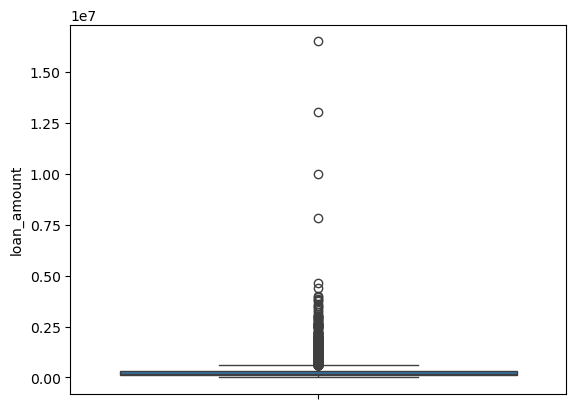

In [26]:
sns.boxplot(HMDA_IL['loan_amount'])
plt.show()

### Ou la methode orienté objet

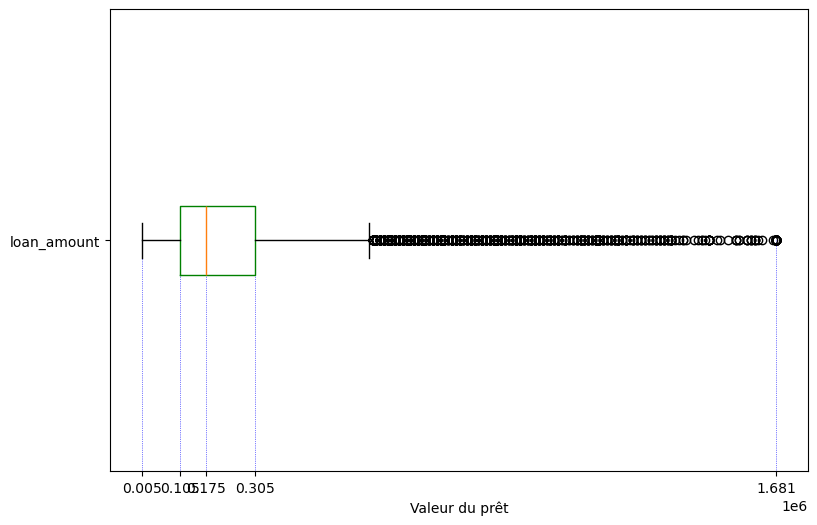

In [27]:
fig = plt.figure(1, figsize=(9, 6))
ax = fig.add_subplot(111)

ax.boxplot(HMDA_IL_clean['loan_amount'], vert=False, manage_ticks=True, boxprops=dict(color='green'))
ax.set_xlabel('Valeur du prêt')
ax.set_yticks([1])
ax.set_yticklabels(['loan_amount'])

quantiles = np.quantile(HMDA_IL_clean['loan_amount'], np.array([0.00, 0.25, 0.50, 0.75, 1.00]))
ax.vlines(quantiles, [0] * quantiles.size, [1] * quantiles.size,
          color='b', ls=':', lw=0.5, zorder=0)
ax.set_ylim(0.5, 1.5)
ax.set_xticks(quantiles)
plt.show()

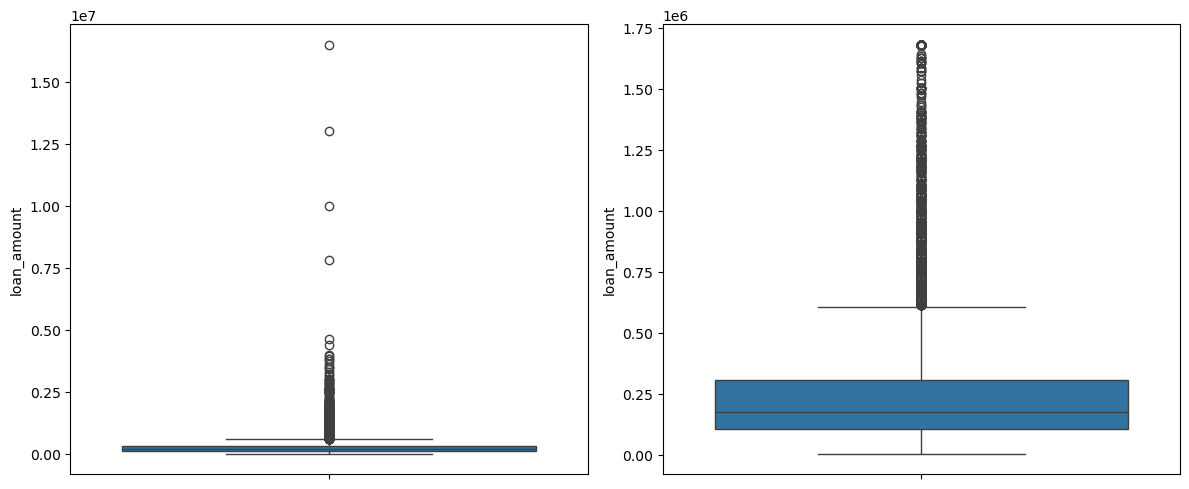

In [28]:
plt.rcParams["figure.figsize"] = [12, 5]
plt.rcParams["figure.autolayout"] = True
f,axes=plt.subplots(1,2)
sns.boxplot(HMDA_IL['loan_amount'],ax=axes[0])
sns.boxplot(HMDA_IL_clean['loan_amount'],ax=axes[1])
plt.show()

In [29]:
# il semble que le taux d'intérêt présente des valeurs aberrantes 
q_h = np.quantile(HMDA_IL_clean['interest_rate'],0.95)
HMDA_IL_clean['interest_rate'] = np.where( HMDA_IL_clean['interest_rate'] > q_h, q_h, HMDA_IL_clean['interest_rate'])

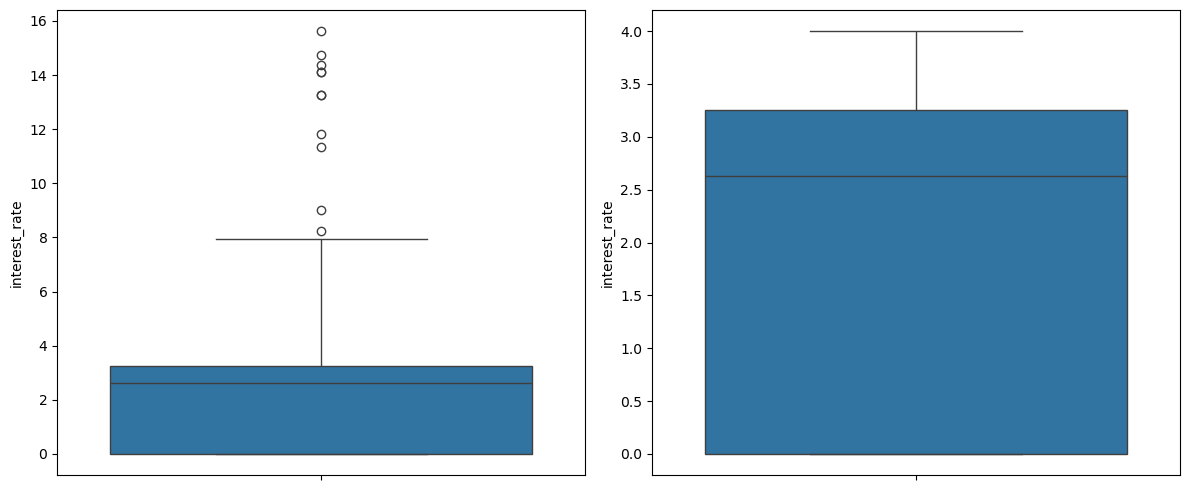

In [30]:
plt.rcParams["figure.figsize"] = [12, 5]
plt.rcParams["figure.autolayout"] = True
f,axes=plt.subplots(1,2)
sns.boxplot(HMDA_IL['interest_rate'],ax=axes[0])
sns.boxplot(HMDA_IL_clean['interest_rate'],ax=axes[1])
plt.show()

### Montant du prêt par race (Box Plot)

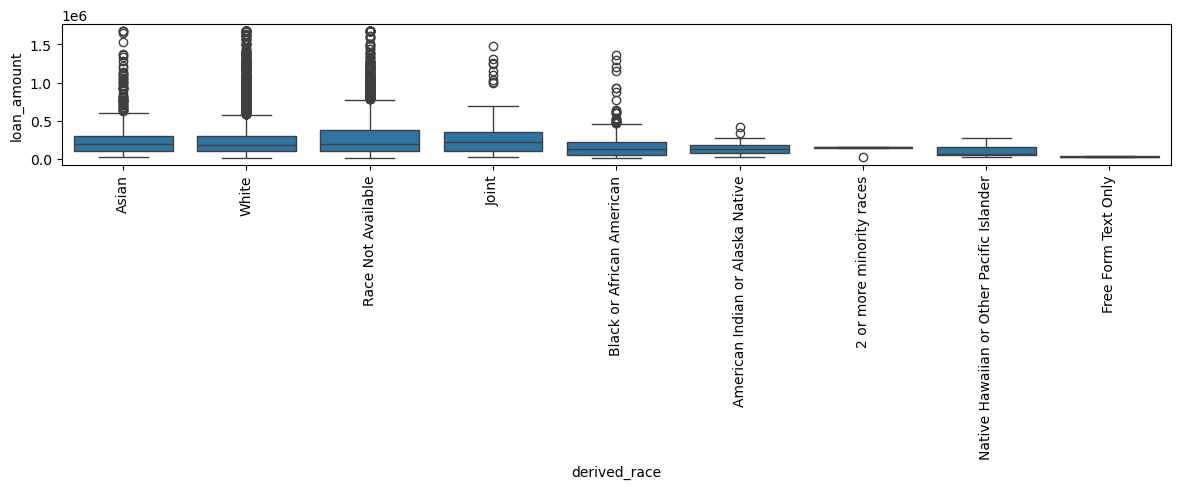

In [31]:
# voyons la répartition des prêts pour différentes ethnies 
sns.boxplot(x=HMDA_IL_clean['derived_race'],y=HMDA_IL_clean['loan_amount'])
plt.xticks(rotation=90)
plt.show()

In [32]:
#Distribution de la variable Race 
HMDA_IL_clean['derived_race'].value_counts(dropna=False)

derived_race
White                                        6232
Race Not Available                           2425
Black or African American                     849
Asian                                         838
Joint                                         149
American Indian or Alaska Native              129
Native Hawaiian or Other Pacific Islander       7
2 or more minority races                        5
Free Form Text Only                             2
Name: count, dtype: int64

In [33]:
#nettoyer la colonne Race 
cleanup_race= {"Black or African American": "Black", "American Indian or Alaska Native": "American Native", "Native Hawaiian or Other Pacific Islander":"Islander","2 or more minority races":"minority races","Free Form Text Only":"Race Not Available"}
HMDA_IL_clean = HMDA_IL_clean.replace(cleanup_race)

In [34]:
HMDA_IL_clean['derived_race'].value_counts(dropna=False)

derived_race
White                 6232
Race Not Available    2427
Black                  849
Asian                  838
Joint                  149
American Native        129
Islander                 7
minority races           5
Name: count, dtype: int64

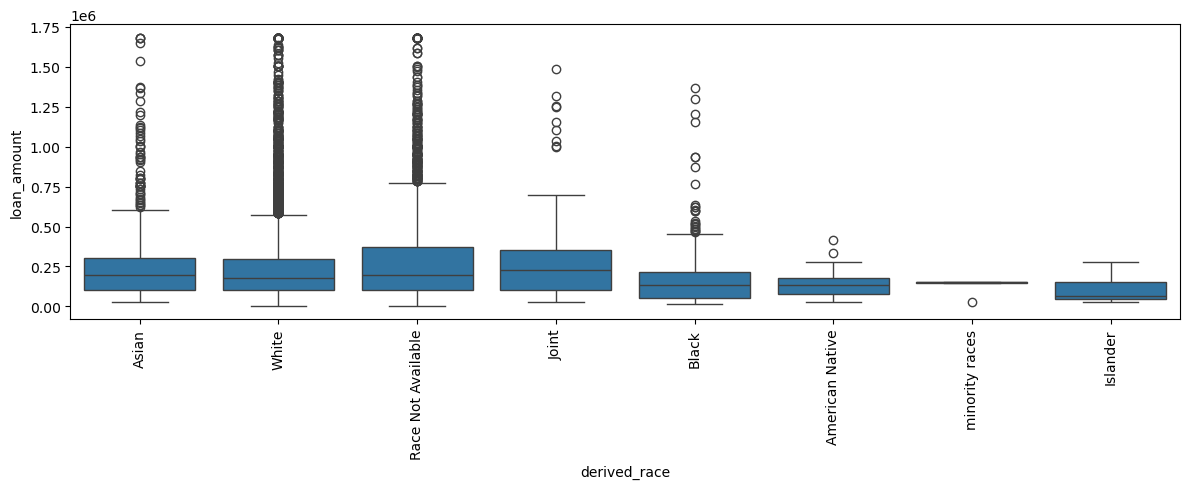

In [35]:
# voyons la répartition des prêts pour différentes ethnies 
sns.boxplot(x=HMDA_IL_clean['derived_race'],y=HMDA_IL_clean['loan_amount'])
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='loan_amount', ylabel='count'>

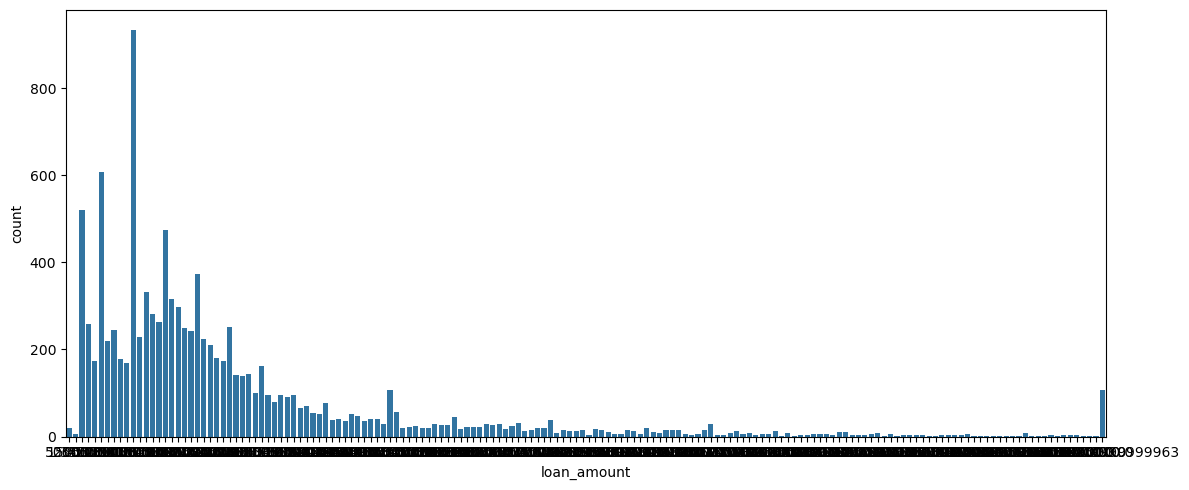

In [36]:
sns.countplot(x="loan_amount", data=HMDA_IL_clean)

### Correlation<a name="correlation"></a>

In [37]:
correlations = HMDA_IL_clean.corr()

fig = plt.figure(figsize=(12, 10))
sns.heatmap(correlations, annot=True, cmap='GnBu_r', center=1)
plt.show()

ValueError: could not convert string to float: 'Asian'

In [ ]:
#Vérifier les valeurs de données dans les colonnes catégorielles 
cat_cols = HMDA_IL_clean.select_dtypes(include='object').columns
for i in cat_cols:
    print('Les observations dans chaque catégorie sont:\n')
    print(HMDA_IL_clean[i].value_counts(dropna=False))
    print('-------------------------------------')

Les observations dans chaque catégorie sont:

derived_race
White                 6232
Race Not Available    2427
Black                  849
Asian                  838
Joint                  149
American Native        129
Islander                 7
minority races           5
Name: count, dtype: int64
-------------------------------------
Les observations dans chaque catégorie sont:

derived_sex
Male                 3515
Joint                3336
Female               2281
Sex Not Available    1504
Name: count, dtype: int64
-------------------------------------
Les observations dans chaque catégorie sont:

action_taken
Approved                     5481
Denied                       3005
Application Withdrawn         899
File Incomplete               437
Approved but not accepted     416
Purchased Loan                398
Name: count, dtype: int64
-------------------------------------


In [ ]:
HMDA_IL_clean.describe(include=['object']).drop('count').T

,unique,top,freq
derived_race,8,White,6232
derived_sex,4,Male,3515
action_taken,6,Approved,5481


### Histogramme du montant du prêt avec ligne normale : écart-type, variance, moyenne, médiane, kurtosis, asymétrie

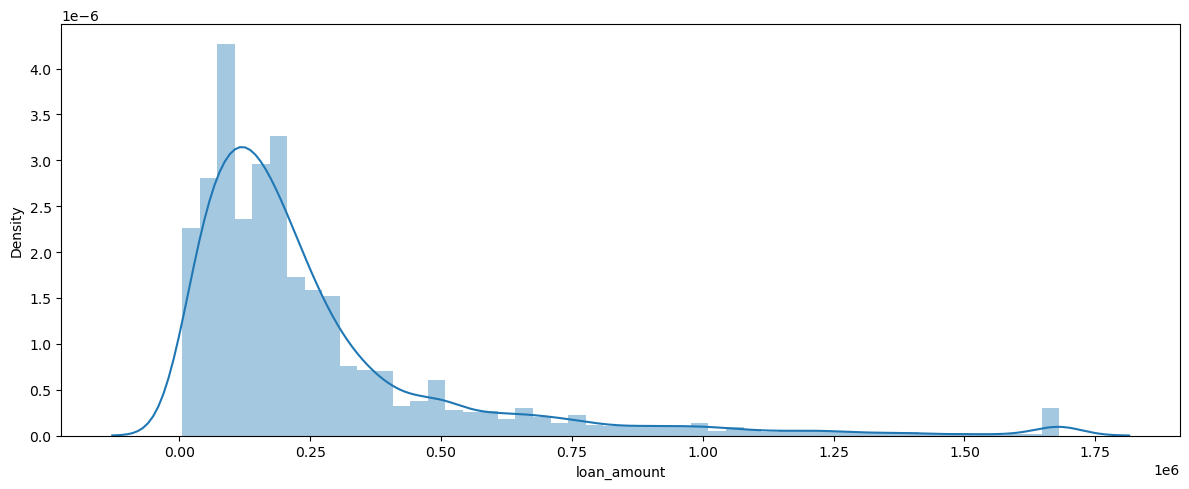

Moyenne: 273373.0
Médiane: 175000.0
Ecart type: 402637.0
Variance: 162116570580.0
Asymétrie: 13.0
Kurtosis: 398.0


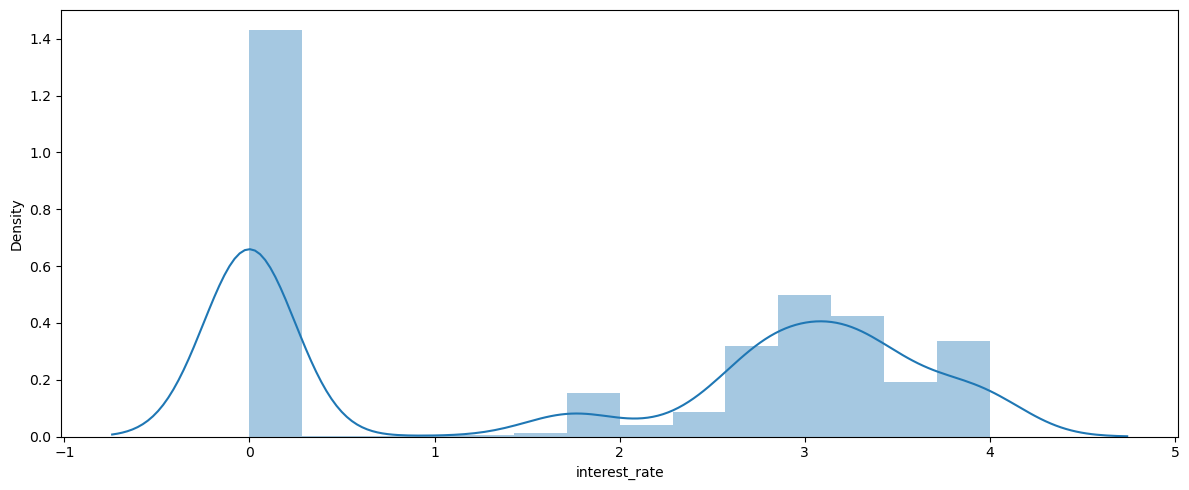

Moyenne: 2.0
Médiane: 2.625
Ecart type: 2.0
Variance: 3.0
Asymétrie: 0.0
Kurtosis: 1.0


In [ ]:
from scipy import stats

l = ['loan_amount', 'interest_rate']
for i in l:
    sns.distplot( HMDA_IL_clean[i])
    plt.show()
    print('Moyenne:',round(HMDA_IL[i].mean(),0))
    print('Médiane:',HMDA_IL[i].median())
    print('Ecart type:',round(HMDA_IL[i].std(),0))
    print('Variance:',round(HMDA_IL[i].var(),0))
    print('Asymétrie:',round(HMDA_IL[i].skew(),0))
    print('Kurtosis:', round(HMDA_IL[i].kurt(),0))

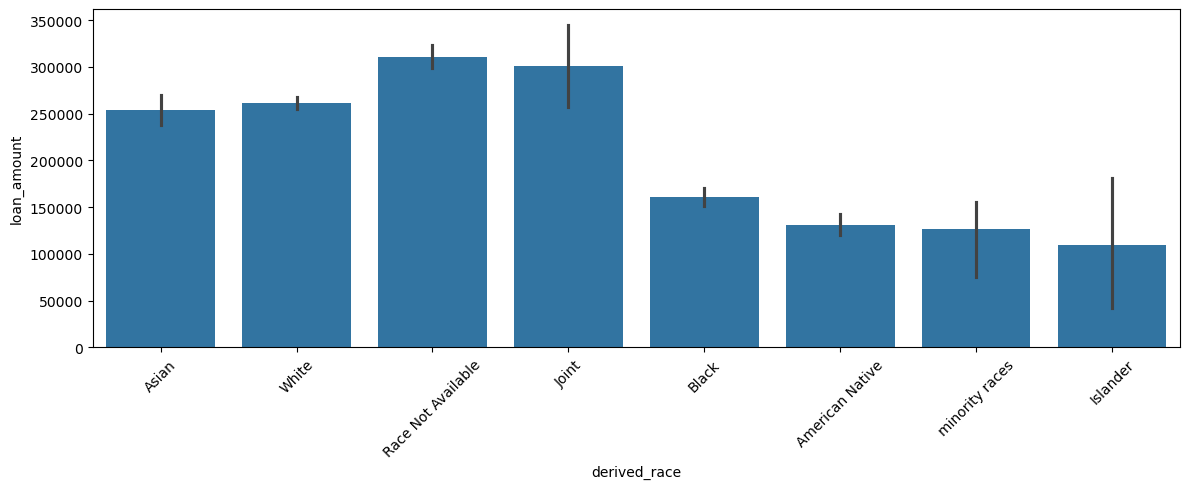

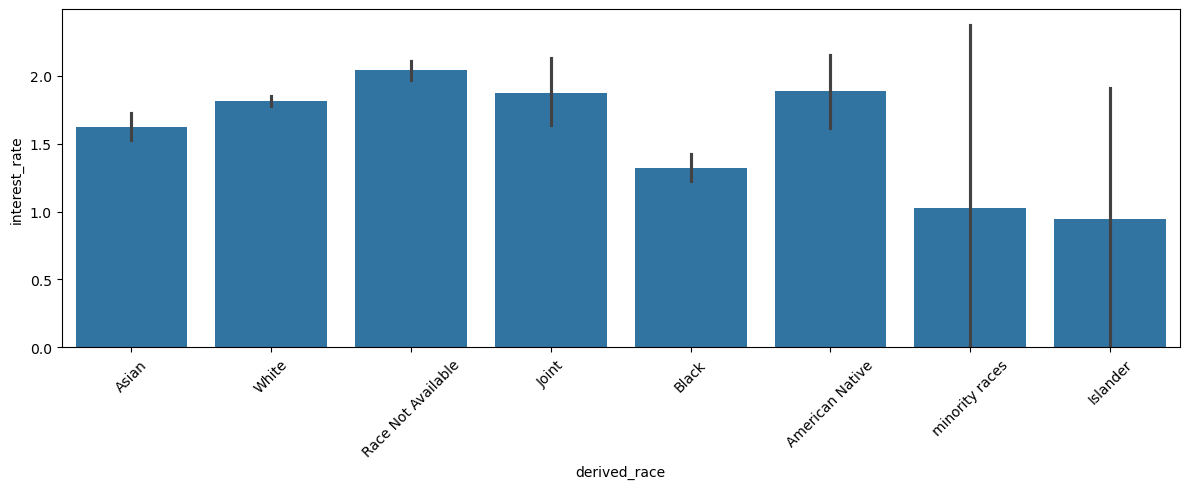

In [ ]:
l = ['loan_amount', 'interest_rate']
for i in l:
    sns.barplot(x=HMDA_IL_clean['derived_race'], y=HMDA_IL_clean[i])
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
#Vérifions si l'approbation du prêt est liée à l'origine ethnique
Approval_vs_Race = pd.crosstab(index=HMDA_IL_clean["derived_race"], columns=HMDA_IL_clean["action_taken"])
Approval_vs_Race

action_taken,Application Withdrawn,Approved,Approved but not accepted,Denied,File Incomplete,Purchased Loan
derived_race,,,,,,
American Native,8,69,4,44,4,0
Asian,74,426,36,265,37,0
Black,65,358,33,359,34,0
Islander,0,2,0,4,1,0
Joint,24,87,4,28,6,0
Race Not Available,208,1053,102,575,91,398
White,520,3484,237,1727,264,0
minority races,0,2,0,3,0,0


In [ ]:
#Analyser le taux d'intérêt moyen par origine ethnique dérivée 
Avg_loan = pd.DataFrame(HMDA_IL_clean['interest_rate'].groupby(HMDA_IL_clean['derived_sex']).max().sort_values(ascending = False))
Avg_loan['Race'] = Avg_loan.index.values
Avg_loan

,interest_rate,Race
derived_sex,,
Female,4.0,Female
Joint,4.0,Joint
Male,4.0,Male
Sex Not Available,4.0,Sex Not Available


### TRI par montant de prêt (nuage de points)

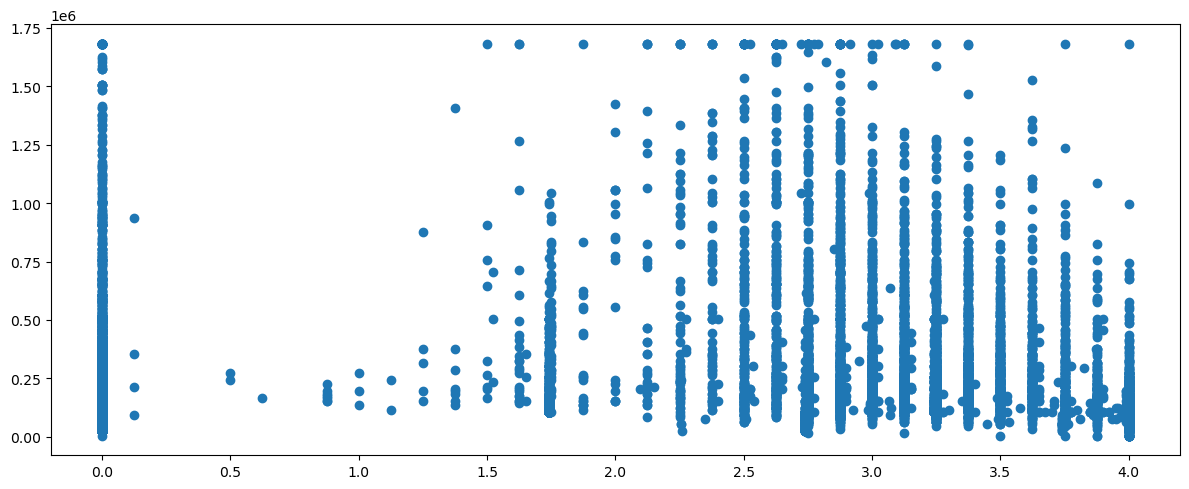

In [ ]:
# Analyze interest rate and Loan amount distribution pattern
plt.scatter(HMDA_IL_clean['interest_rate'],HMDA_IL_clean['loan_amount'])
plt.show()

<Axes: xlabel='derived_race'>

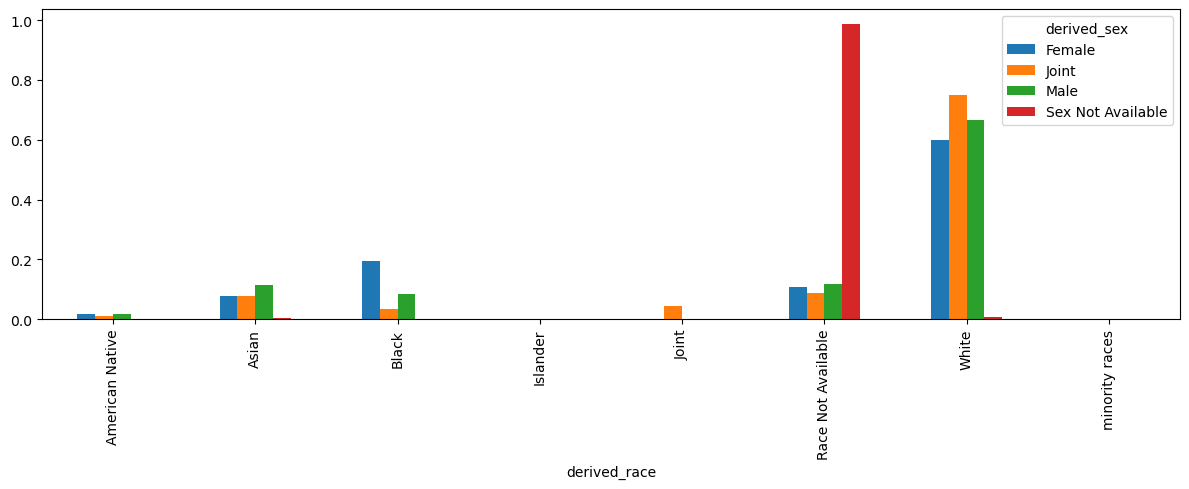

In [ ]:
pd.crosstab(HMDA_IL_clean['derived_race'],HMDA_IL_clean['derived_sex'],normalize = 'columns' ).plot(kind='bar')

In [ ]:
HMDA_IL_clean.groupby(by=['derived_race','derived_sex'])['loan_amount'].mean()

derived_race        derived_sex      
American Native     Female               143648.648649
                    Joint                132058.823529
                    Male                 123070.175439
                    Sex Not Available     75000.000000
Asian               Female               196257.142857
                    Joint                292389.534884
                    Male                 255952.736318
                    Sex Not Available    118333.333333
Black               Female               152168.539326
                    Joint                191909.090909
                    Male                 161198.630137
                    Sex Not Available    115000.000000
Islander            Female                55000.000000
                    Male                 181666.666667
Joint               Female               328333.333333
                    Joint                297340.425532
                    Male                 371000.000000
Race Not Available  Female 

<Axes: xlabel='derived_race', ylabel='loan_amount'>

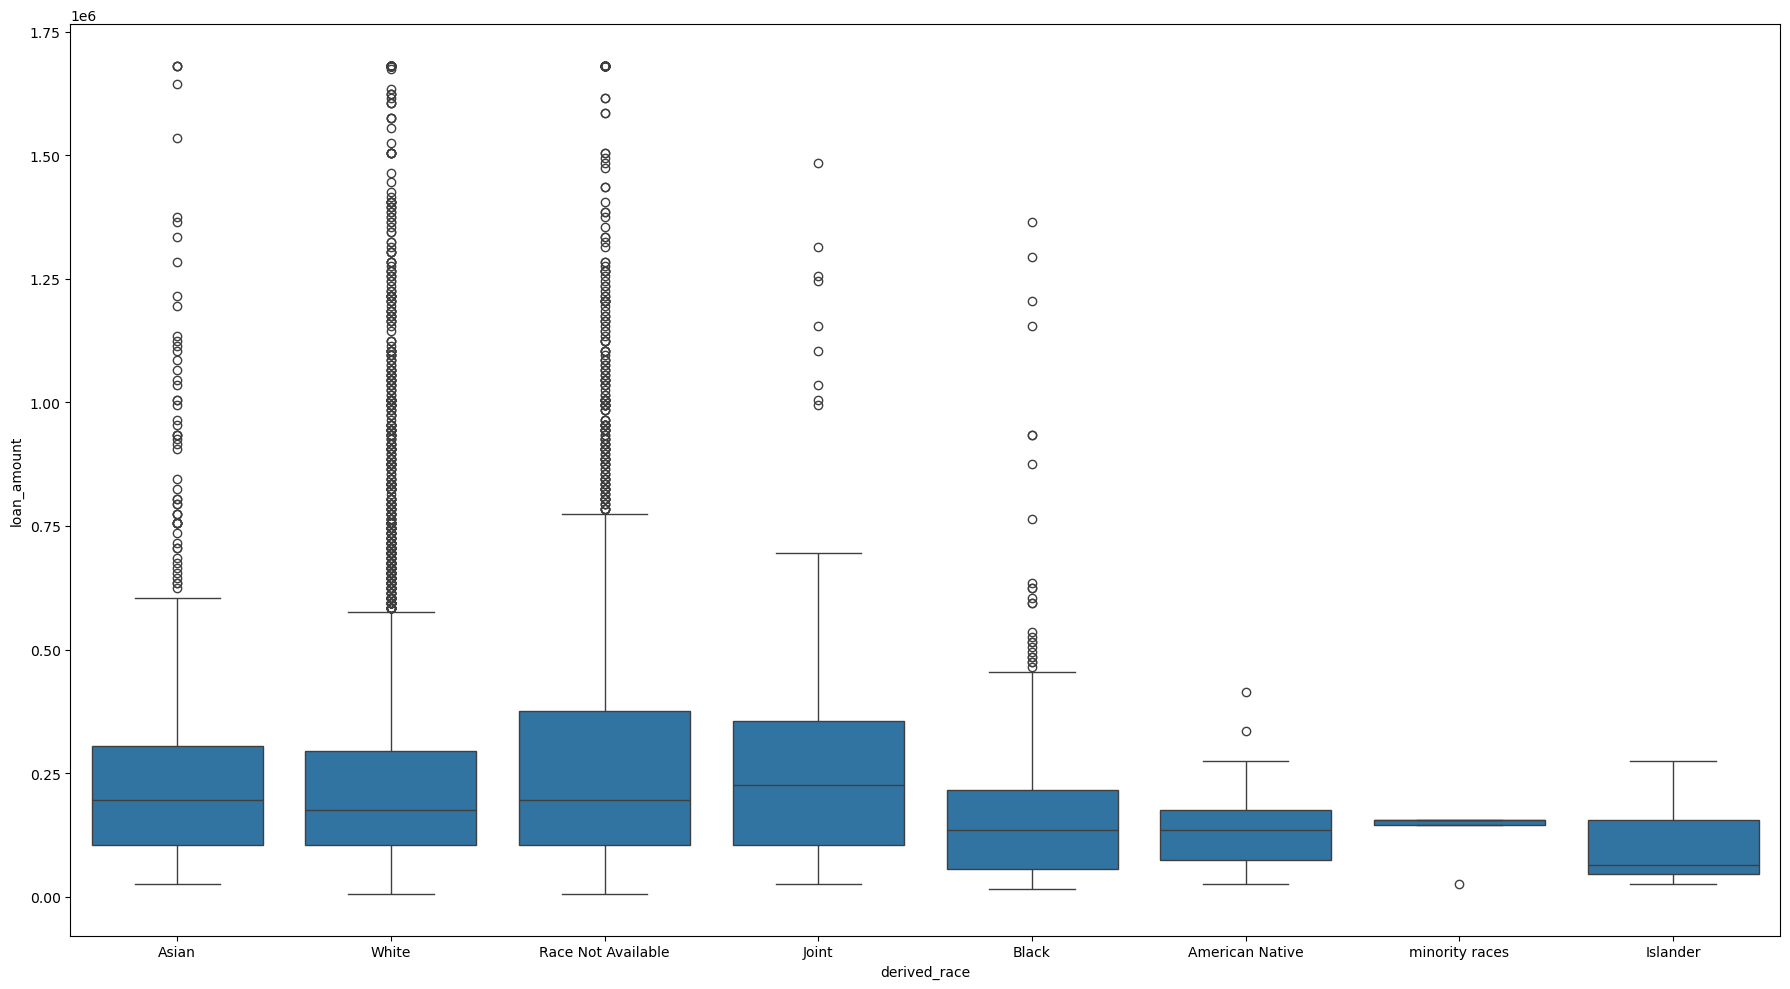

In [ ]:
plt.figure(figsize=(18,10))
sns.boxplot(x='derived_race',y='loan_amount',data=HMDA_IL_clean)

### Histogramme avec ligne normale


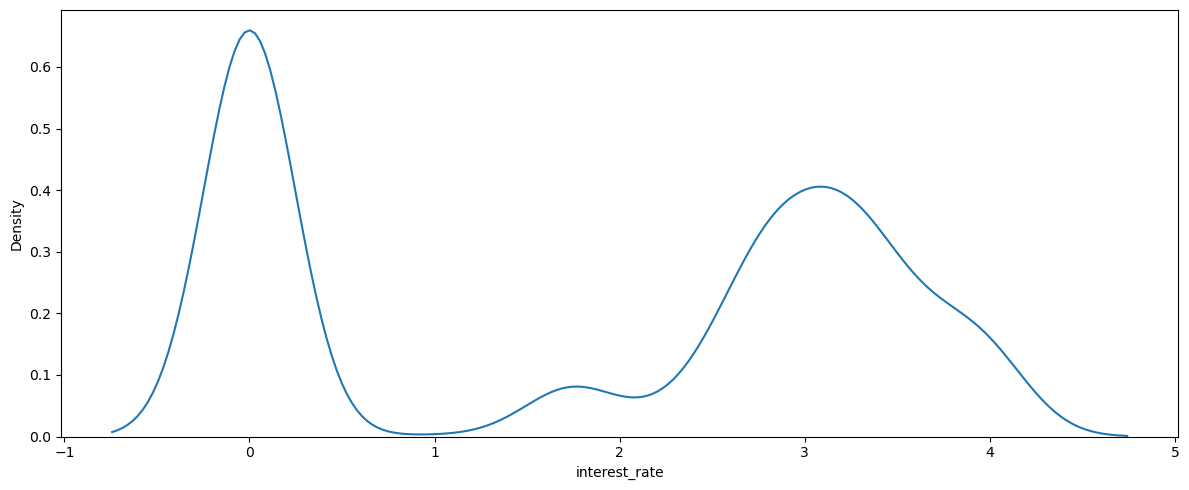

In [ ]:
num_col=['interest_rate']
num_col[0]
for i in num_col:
    plt.figure()
    sns.kdeplot(HMDA_IL_clean[i])
plt.show()

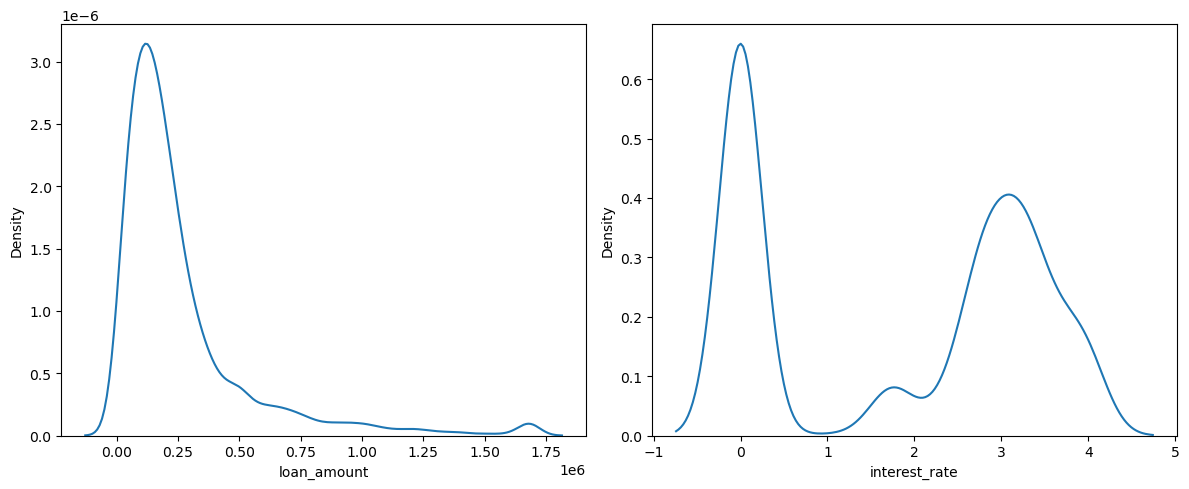

In [ ]:
f,axes=plt.subplots(1,2)
sns.kdeplot(HMDA_IL_clean['loan_amount'],ax=axes[0])
sns.kdeplot(HMDA_IL_clean['interest_rate'],ax=axes[1])
plt.show()

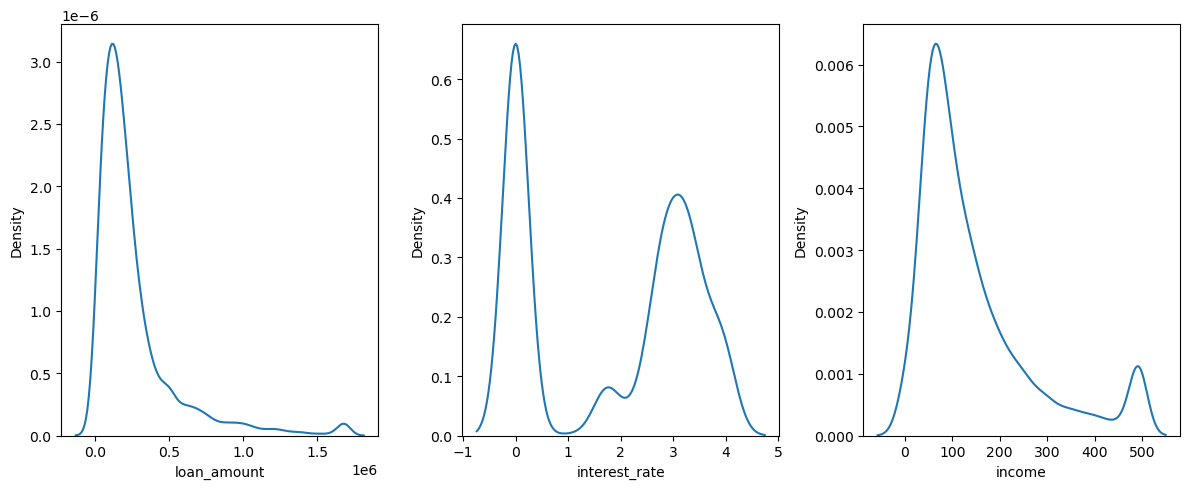

In [ ]:
f,axes=plt.subplots(1,3)
sns.kdeplot(HMDA_IL_clean['loan_amount'],ax=axes[0])
sns.kdeplot(HMDA_IL_clean['interest_rate'],ax=axes[1])
sns.kdeplot(HMDA_IL_clean['income'],ax=axes[2])
plt.show()

### Binomial, Bernaoulli, Poisson Distribution <a name="distribution"></a>

In [ ]:
# Distribution Binomial
import scipy.stats as stats
#D'après les données historiques, nous savons que 70 % des clients règlent leur facture de carte de crédit à temps.
p=.7
#Si un échantillon de 6 titulaires de comptes est sélectionné au hasard, alors
n = 6

In [ ]:
k=np.arange(0,7)
k

array([0, 1, 2, 3, 4, 5, 6])

In [ ]:
binomial = stats.binom.pmf(k,n,p)
binomial

array([0.000729, 0.010206, 0.059535, 0.18522 , 0.324135, 0.302526,
       0.117649])

In [ ]:
sum(binomial)

np.float64(0.9999999999999997)

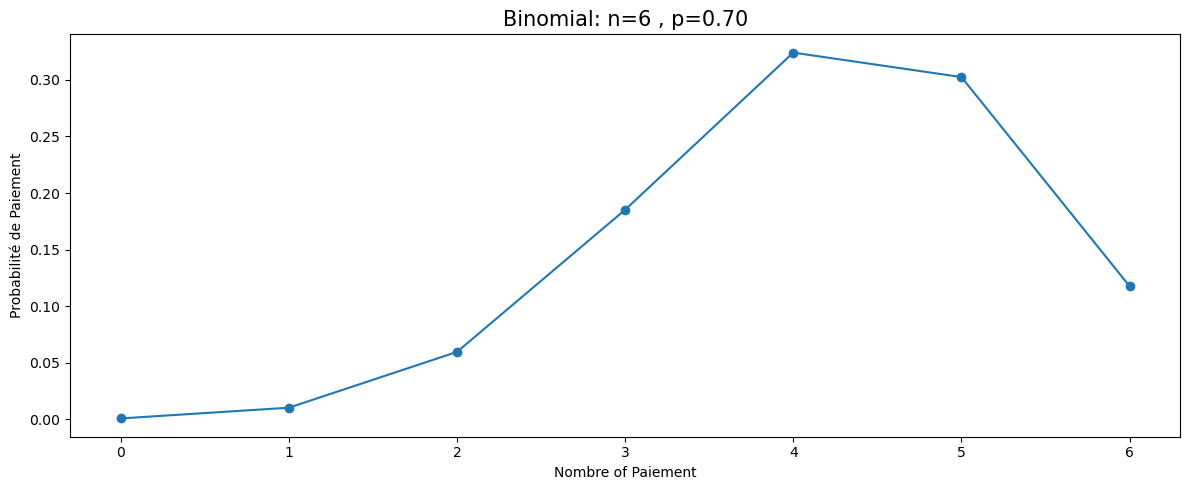

In [ ]:
plt.plot(k,binomial,'o-')
plt.title('Binomial: n=%i , p=%.2f' % (n,p), fontsize=15)
plt.xlabel('Nombre of Paiement')
plt.ylabel('Probabilité de Paiement')
plt.show()

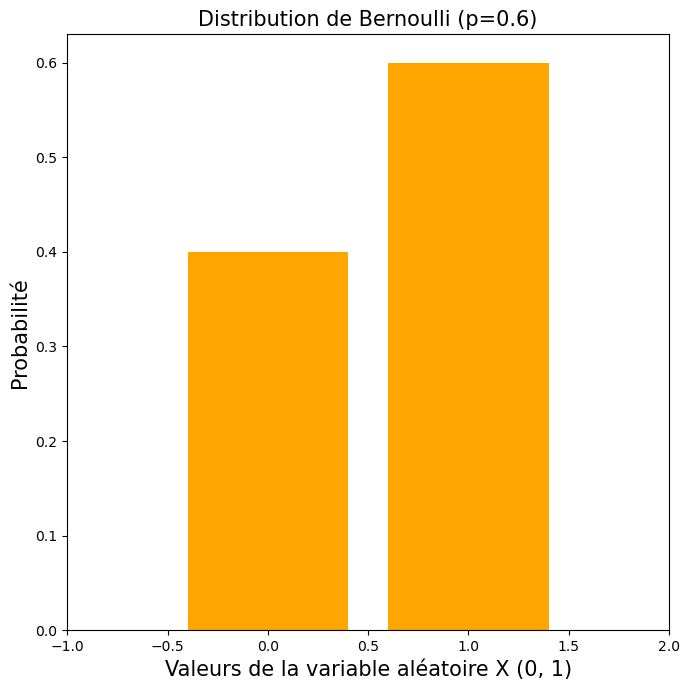

In [ ]:
# Distribution de Bernoulli
from scipy.stats import bernoulli
# Distribution de Bernoulli avec paramètre p = 0,6
bd = bernoulli(0.6)
# Le résultat de l'expérience ne pourra prendre que les valeurs 0 ou 1
X = [0, 1]

plt.figure(figsize=(7,7))
plt.xlim(-1, 2)
plt.bar(X, bd.pmf(X), color='orange')
plt.title('Distribution de Bernoulli (p=0.6)', fontsize='15')
plt.xlabel('Valeurs de la variable aléatoire X (0, 1)', fontsize='15')
plt.ylabel('Probabilité', fontsize='15')
plt.show()

In [ ]:
#Distribution de Poisson 
from scipy.stats import poisson
#3 appels par minutes
rate = 3
n=np.arange(0,10)

In [ ]:
#calculer la distribution et stocker la distribution des probabilités dans un tableau
poisson = stats.poisson.pmf(n,rate)
poisson

array([0.04978707, 0.14936121, 0.22404181, 0.22404181, 0.16803136,
       0.10081881, 0.05040941, 0.02160403, 0.00810151, 0.0027005 ])

In [ ]:
#probabilité de plus de 3 appels par minute étant donné une moyenne de 3 appels par minute
1 - (poisson[0]+poisson[1]+poisson[2]+poisson[3])

np.float64(0.35276811121776874)

In [ ]:
# Autre possibilité / Probabilité que plus de 3 appels arrivent dans la prochaine minute
1 - stats.poisson.cdf(k=3,mu=3)

np.float64(0.35276811121776874)

In [ ]:
#probabilité que x>= 2, c'est-à-dire la probabilité d'au moins 2 appels par minute étant donné une moyenne de 3 appels par minute
1 - (poisson[0]+poisson[1])

np.float64(0.8008517265285442)

In [ ]:
#autre chemin
1 - stats.poisson.cdf(k=1,mu=3)

np.float64(0.8008517265285442)

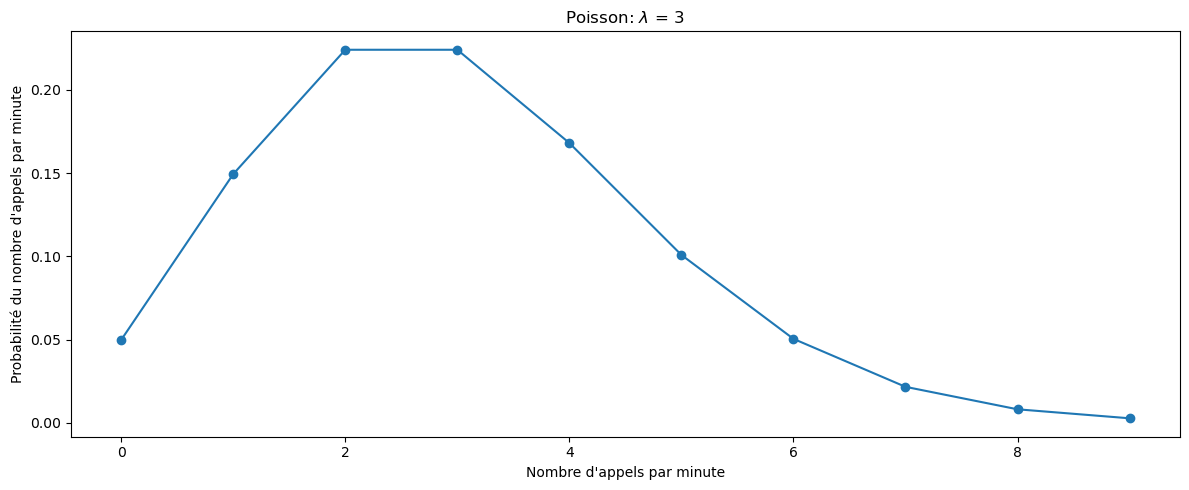

In [ ]:
plt.plot(n,poisson,'o-')
plt.title('Poisson: $\lambda$ = %i ' % rate)
plt.xlabel("Nombre d'appels par minute")
plt.ylabel("Probabilité du nombre d'appels par minute")
plt.show()

### Distribution Log Normale 

In [ ]:
# moyenne= 3 and écart-type= 1
mu, sigma = 3, 1 
s = np.random.lognormal(mu, sigma, 1000)

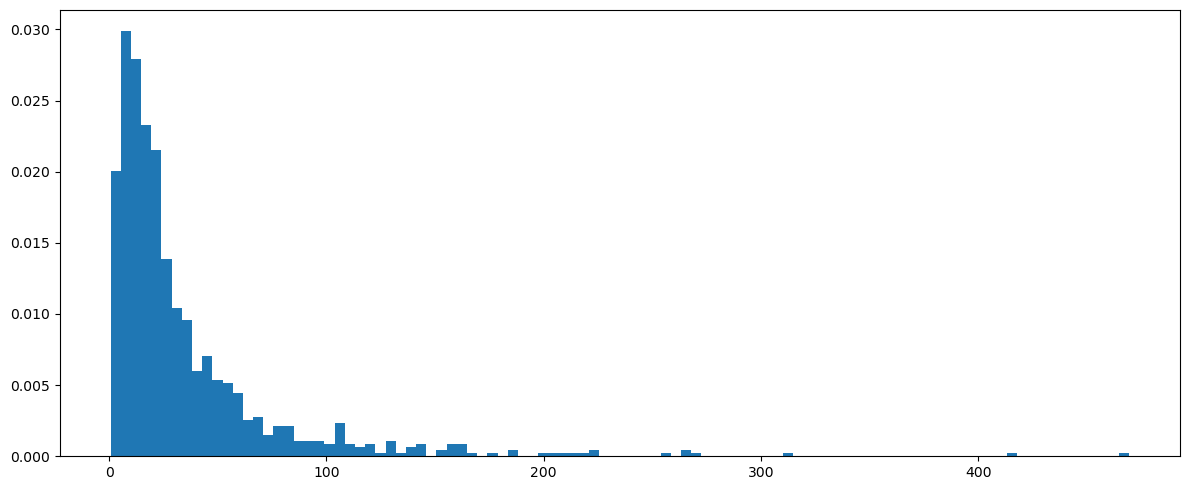

In [ ]:
Count, bins, ignored = plt.hist(s, 100, density=True, align='mid')

### Distribution Exponentielle

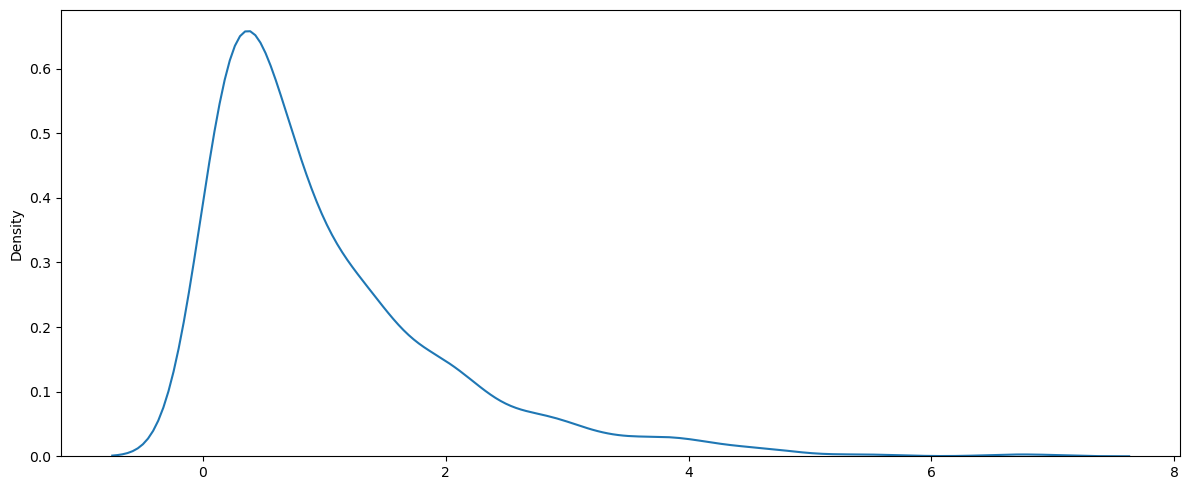

In [ ]:
# La distribution de Poisson traite du nombre d'occurrences d'un événement dans une période de temps, tandis que la distribution de Poisson traite du nombre d'occurrences d'un événement dans une période de temps donnée.
# La distribution exponentielle traite du temps entre ces événements.

from numpy import random
import matplotlib.pyplot as plt


sns.distplot(random.exponential(size=1000), hist=False)

plt.show()

### Boîte à moustache (Boxplot) du genre et de l'IR, test t (2 échantillons pour le genre et l'IR), ANOVA – Race par IR


([0, 1, 2, 3],
 [Text(0, 0, 'Female'),
  Text(1, 0, 'Joint'),
  Text(2, 0, 'Male'),
  Text(3, 0, 'Sex Not Available')])

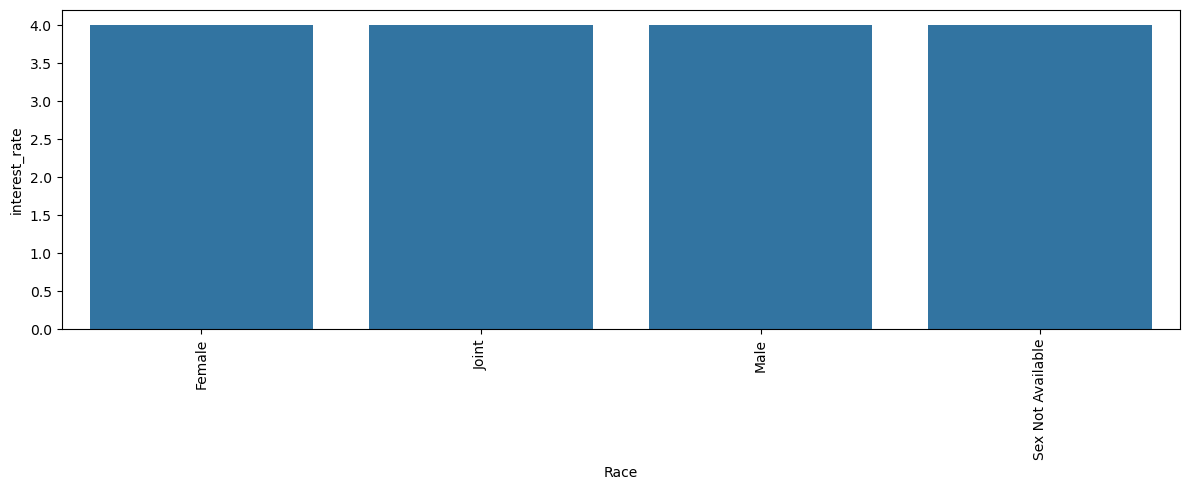

In [ ]:
sns.barplot(y='interest_rate' ,x= 'Race',data=Avg_loan)
plt.xticks(rotation=90)

<Axes: xlabel='derived_sex', ylabel='interest_rate'>

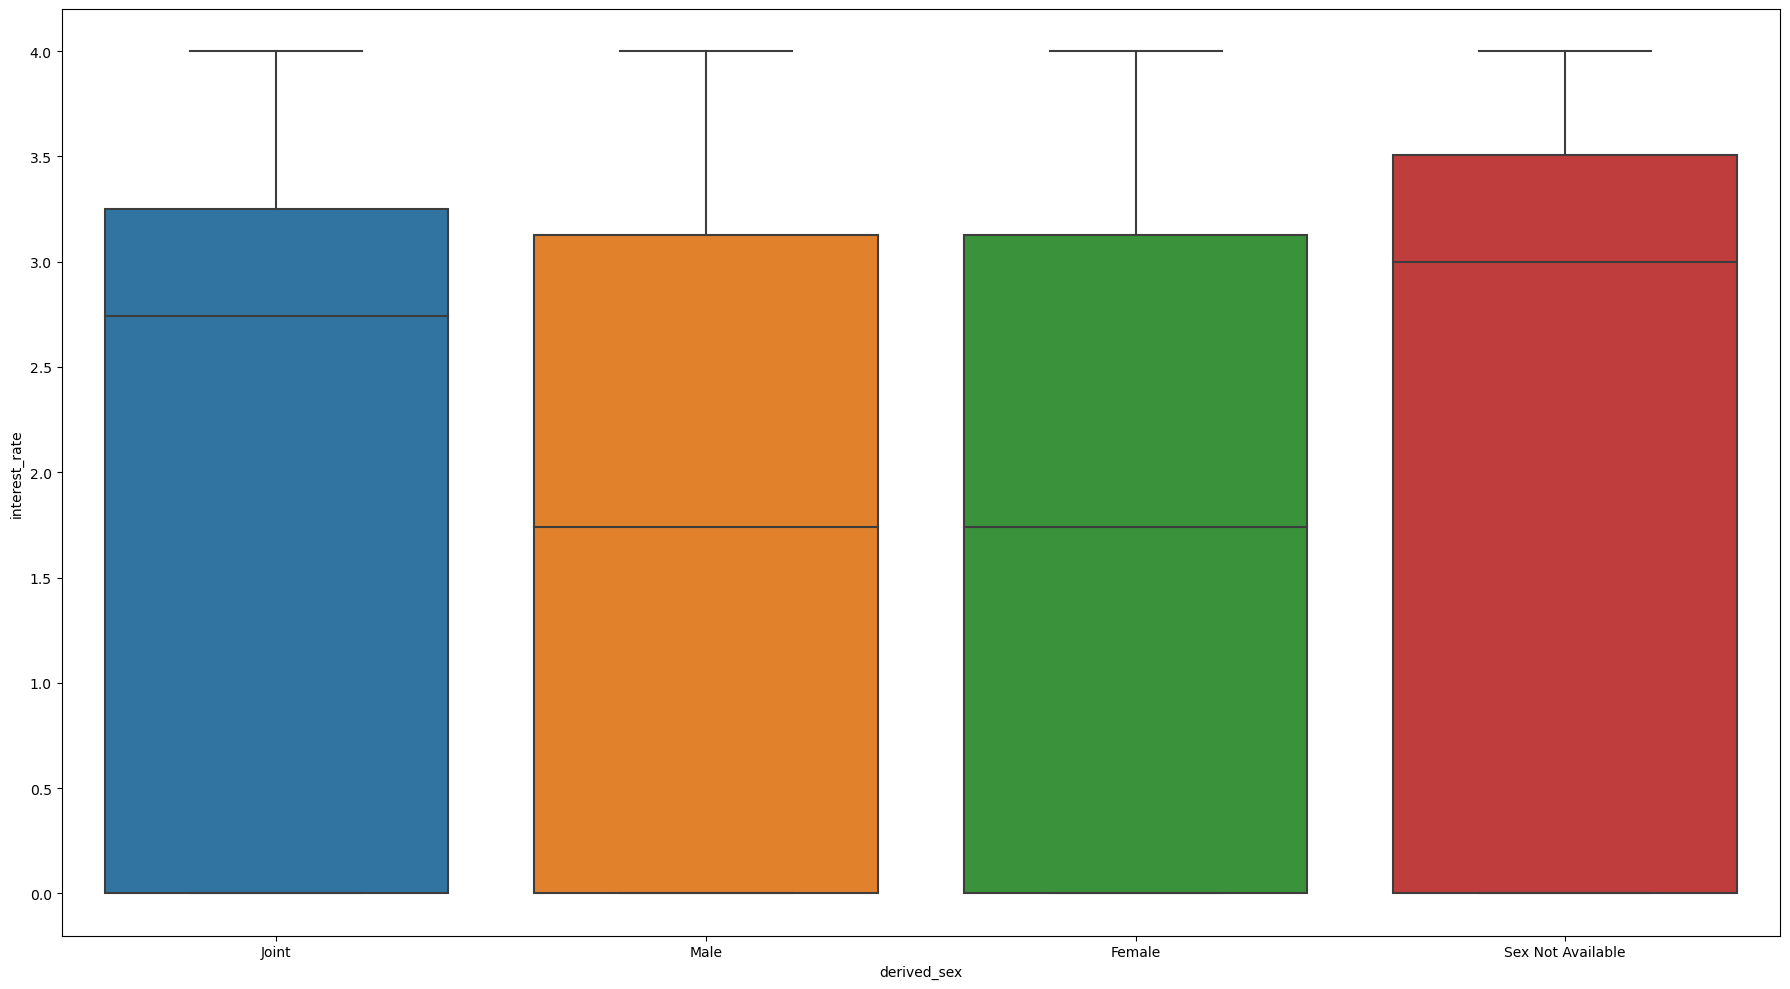

In [ ]:
plt.figure(figsize=(18,10))
sns.boxplot(x='derived_sex',y='interest_rate',data=HMDA_IL_clean)

### Test Statistique <a name="test"></a>

In [ ]:
#Effectuons un test statistique. Nous savons que le taux d'intérêt moyen est de 2,62. 
#Premièrement, importons la bibliothèque requise.

from scipy.stats import ttest_1samp, wilcoxon
from statsmodels.stats.power import ttest_power
# Test t à un échantillon 
# Hypothèse nulle : valeur attendue = 2.62

t_statistic, p_value = ttest_1samp(HMDA_IL_clean.interest_rate, 2.62)
print(t_statistic, p_value)

-52.62773342109528 0.0


In [ ]:
t_statistic, p_value = ttest_1samp(HMDA_IL_clean.loan_amount, 175000)
print(t_statistic,p_value)

31.926376485265873 1.134506714357613e-213


### Test-t à un échantillon

In [ ]:
# p-value > 0,05 => On ne rejette pas l'hypothèse nulle : 
# # les données ne s'écartent pas significativement de l'hypothèse selon laquelle la moyenne 
# est de 3,05 au seuil de signification de 5 %

print ("test-t à un échantillon, p-value=", p_value)

test-t à un échantillon, p-value= 1.134506714357613e-213


### Test-t 2 échantillons

In [ ]:
#Test-t à 2 échantillons
from scipy.stats import ttest_ind
df0=HMDA_IL_clean[HMDA_IL_clean['derived_sex']=='Male']
df1=HMDA_IL_clean[HMDA_IL_clean['derived_sex']=='Female']

In [ ]:
_,pval=ttest_ind(df0['interest_rate'],df1['interest_rate'])

In [ ]:
pval
#Pval is greater than 0.05, therefore we fail to reject H0.
# We go by the H0
# average interest of male group is equal to average interest rate of female group 

#La p-value étant supérieure à 0.05, nous ne rejetons pas H0. 
# Nous adoptons l'hypothèse nulle H0 : 
# le taux d'intérêt moyen du groupe masculin est égal au taux d'intérêt moyen du groupe féminin.

0.4319306829179371

### Test-t apparié

In [ ]:
#suppose there are some marketing campaign done on credit card spend. Test is the there effective change in there credit card depnd
#before and after campaign at the 0.05 level of significance

# Supposons qu'une campagne marketing soit menée sur les dépenses par carte de crédit. 
# Le test porte sur le changement effectif de ces dépenses avant et après la campagne, au seuil de signification de 0,05.
spend_before_campaign = np.array([150,180,200,350,416,425,440])
spend_after_campaign = np.array([280,215,111,220,390,175,300])
sample_size = len(spend_after_campaign)
sample_size

7

In [ ]:
# H0 : La différence moyenne des dépenses par carte avant et après est nulle. H1 : La différence moyenne des dépenses par carte avant et après n’est pas nulle. 

# Seuil de signification = 0,05
stats.ttest_rel(spend_after_campaign, spend_before_campaign)

TtestResult(statistic=np.float64(-1.4180124279929727), pvalue=np.float64(0.20597132980745858), df=np.int64(6))

In [ ]:
t_critical = stats.t.isf(0.05,sample_size-1)
print(t_critical)

1.9431802805153024


In [ ]:
# Comme la p-value est supérieure au seuil de signification, nous devons accepter l'hypothèse nulle. Cela signifie qu'il n'y a pas de différence de dépenses avant et après la campagne. 
# De plus, la statistique t du test étant inférieure à la valeur t critique, nous devons accepter l'hypothèse nulle.

In [ ]:
### Intervalle de confiance
difference = spend_after_campaign-spend_before_campaign
mean_difference = np.mean(difference)
sd_difference = np.std(difference)
se_difference = sd_difference/np.sqrt(sample_size)
stats.t.interval(0.95, (sample_size-1), mean_difference, se_difference)

(np.float64(-174.40950534877453), np.float64(40.12379106306025))

###  Test de Levene

In [ ]:
stats.levene(df0['interest_rate'],df1['interest_rate'])

LeveneResult(statistic=np.float64(6.248832544770106), pvalue=np.float64(0.012454955729974043))

### Test Shapiro-Wilk

In [ ]:
#Test de normalité / Effectuer le test de Shapiro-Wilk pour vérifier la normalité 
# shapiro() renvoie un tuple contenant les valeurs des statistiques de test et la p-valeur correspondante

from scipy.stats import shapiro
stat, p_value = shapiro(HMDA_IL_clean['interest_rate'])

# On affiche la p-value correspondante
print('P-Value:', p_value)

P-Value: 3.006243103996014e-79


In [ ]:
# D'après le résultat ci-dessus, nous pouvons voir que la p-valeur est inférieure à 0,05, 
# donc nous pouvons dire que le taux d'intérêt n'est pas distribué normalement.

In [ ]:
HMDA_IL_clean['log_interest_rate']=pd.Series(np.sqrt(HMDA_IL_clean['interest_rate']))

In [ ]:
stat, p_value = shapiro(HMDA_IL_clean['log_interest_rate'])

# print the corresponding p-value 
print('P-Value:', p_value)

P-Value: 2.8929093690489864e-85


In [ ]:
# import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model = ols('interest_rate ~ derived_sex', data = HMDA_IL_clean).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                   sum_sq       df           F        PR(>F)
derived_sex    795.814812      3.0  109.744509  5.595653e-70
Residual     25699.396858  10632.0         NaN           NaN


In [ ]:
# Dans l'exemple ci-dessus, la p-value est de 0,330994 et elle est supérieure au seuil de signification choisi de 5 %. 

# La décision statistique est donc d'accepter l'hypothèse nulle au seuil de signification de 5 %. 

# Il existe donc des preuves suffisantes pour accepter l'hypothèse nulle selon laquelle au moins un taux d'intérêt moyen diffère selon le sexe.

### Anova

In [ ]:
#Anova
mean_time_df = pd.DataFrame()

df1            = pd.DataFrame({'Groupe': 'A', 'Temps_moyen': [10.65, 10.5, 10.7, 12.8, 15.5, 7.5, 7.8, 11.5, 10.65, 8.9]})
df2            = pd.DataFrame({'Groupe': 'B', 'Temps_moyen': [10.43, 10.6, 10.7, 12.75, 13.5, 8.5, 6.8, 11.5, 10.65, 8.9]})
df3            = pd.DataFrame({'Groupe': 'C', 'Temps_moyen': [6.7, 5.3, 4.7, 10.2, 8.5, 6.51, 4.7, 8.5, 4.6, 8]})
df4            = pd.DataFrame({'Groupe': 'D', 'Temps_moyen': [8.7, 9.5, 8.7, 10.2, 8.7, 7.5, 12.7, 8.5, 9.5, 9.7]})

#mean_time_df = mean_time_df.append(df1) 
#mean_time_df = mean_time_df.append(df2) 
#mean_time_df = mean_time_df.append(df3) 
#mean_time_df = mean_time_df.append(df4)

mean_time_df = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [ ]:
# Anova


df1 = pd.DataFrame({
    'Groupe': 'A',
    'Temps_moyen': [10.65, 10.5, 10.7, 12.8, 15.5, 7.5, 7.8, 11.5, 10.65, 8.9]
})

df2 = pd.DataFrame({
    'Groupe': 'B',
    'Temps_moyen': [10.43, 10.6, 10.7, 12.75, 13.5, 8.5, 6.8, 11.5, 10.65, 8.9]
})

df3 = pd.DataFrame({
    'Groupe': 'C',
    'Temps_moyen': [6.7, 5.3, 4.7, 10.2, 8.5, 6.51, 4.7, 8.5, 4.6, 8]
})

df4 = pd.DataFrame({
    'Groupe': 'D',
    'Temps_moyen': [8.7, 9.5, 8.7, 10.2, 8.7, 7.5, 12.7, 8.5, 9.5, 9.7]
})

mean_time_df = pd.concat([df1, df2, df3, df4], ignore_index=True)

mean_time_df.head()

,Groupe,Temps_moyen
0,A,10.65
1,A,10.50
2,A,10.70
3,A,12.80
4,A,15.50


In [ ]:
mean_time_df.mean(numeric_only=True)

Temps_moyen    9.306
dtype: float64

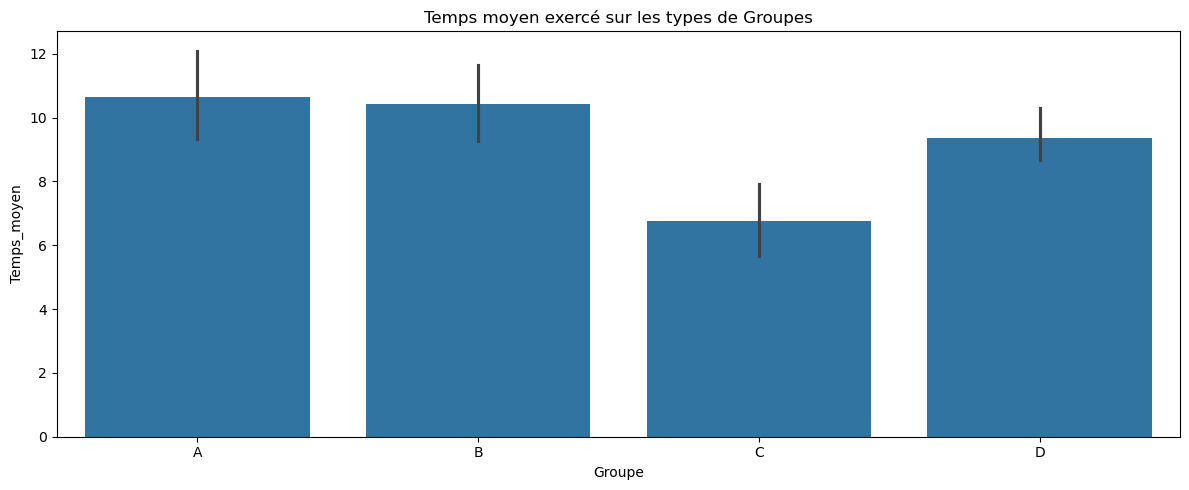

In [ ]:
sns.barplot(x = "Groupe", y = "Temps_moyen", data = mean_time_df)
plt.title('Temps moyen exercé sur les types de Groupes')
plt.show()

In [ ]:
import statsmodels.api         as     sm
from   statsmodels.formula.api import ols
 
mod = ols('Temps_moyen ~ Groupe', data = mean_time_df).fit()
aov_table = sm.stats.anova_lm(mod, typ=2)
print(aov_table)

             sum_sq    df        F    PR(>F)
Groupe     95.06786   3.0  8.28829  0.000254
Residual  137.64170  36.0      NaN       NaN


In [ ]:
df1 = [10.65, 10.5, 10.7, 12.8, 15.5, 7.5, 7.8, 11.5, 10.65, 8.9]
df2 = [10.43, 10.6, 10.7, 12.75, 13.5, 8.5, 6.8, 11.5, 10.65, 8.9]
df3 = [6.7, 5.3, 4.7, 10.2, 8.5, 6.51, 4.7, 8.5, 4.6, 8]
df4 = [8.7, 9.5, 8.7, 10.2, 8.7, 7.5, 12.7, 8.5, 9.5, 9.7]

In [ ]:
# On Importi les bibliothèques
from scipy.stats import f_oneway
# On Effectue l'ANOVA à un facteur
f_oneway(df1,df2,df3,df4)

F_onewayResult(statistic=np.float64(8.288289958638988), pvalue=np.float64(0.0002541809292085698))

### Chi 2

In [ ]:
#Chi carré/différence par rapport au nombre de livres est due à l'arrondi des valeurs attendues
import scipy.stats as stats
import scipy

observed_values    = np.array([35, 20, 30, 25])
n                  = observed_values.sum()

expected_values    = np.array([n*0.45, n*0.30, n*0.1, n*0.15])

chi_square_stat, p_value = stats.chisquare(observed_values, f_exp=expected_values)

print('Au seuil de signification de 5 %s, la statistique du chi carré est de %1.7f' %('%', chi_square_stat)) 
print('Au seuil de signification de 5 %s, la p-valeur est de %1.7f' %('%', p_value))

Au seuil de signification de 5 %, la statistique du chi carré est de 46.5656566
Au seuil de signification de 5 %, la p-valeur est de 0.0000000


In [ ]:
Visit_Time_array = np.array([[25, 50, 75],[100, 150, 100]])
chi_sq_Stat, p_value, deg_freedom, exp_freq = stats.chi2_contingency(Visit_Time_array,correction=False)

print('Statistique du chi carré %3.5f Valeur p %1.6f Degrés de liberté %d' %(chi_sq_Stat, p_value,deg_freedom))

Statistique du chi carré 22.10884 Valeur p 0.000016 Degrés de liberté 2


In [ ]:
exp_freq

array([[ 37.5,  60. ,  52.5],
       [ 87.5, 140. , 122.5]])

### Introduction aux données de séries temporelles <a name="ts"></a>

In [ ]:
#Import a data
df=pd.read_csv('Input Data/data.csv')

In [ ]:
df.head()

,Date,Closing
0,04-12-2020,1411.60
1,07-12-2020,1414.30
2,08-12-2020,1441.70
3,09-12-2020,1437.95
4,10-12-2020,1442.70


In [ ]:
df.tail()

,Date,Closing
254,25-11-2021,4576.55
255,26-11-2021,4597.90
256,29-11-2021,4625.55
257,30-11-2021,4547.35
258,01-12-2021,4591.05


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     259 non-null    object 
 1   Closing  259 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.2+ KB


In [ ]:
#convertir une date en date de série temporelle
from pandas.tseries.offsets import BDay
date = pd.date_range(start='02/04/2020', end='12/02/2021', freq=BDay())
date

DatetimeIndex(['2020-02-04', '2020-02-05', '2020-02-06', '2020-02-07',
               '2020-02-10', '2020-02-11', '2020-02-12', '2020-02-13',
               '2020-02-14', '2020-02-17',
               ...
               '2021-11-19', '2021-11-22', '2021-11-23', '2021-11-24',
               '2021-11-25', '2021-11-26', '2021-11-29', '2021-11-30',
               '2021-12-01', '2021-12-02'],
              dtype='datetime64[ns]', length=478, freq='B')

In [ ]:
#Définir la colonne de date comme index
df['TimeStamp']=pd.DataFrame(date,columns=['date'])
df = df.set_index('TimeStamp')
df=df.drop('Date',axis=1)
df

,Closing
TimeStamp,
2020-02-04,1411.60
2020-02-05,1414.30
2020-02-06,1441.70
2020-02-07,1437.95
2020-02-10,1442.70
...,...
2021-01-25,4576.55
2021-01-26,4597.90
2021-01-27,4625.55


<Axes: xlabel='TimeStamp'>

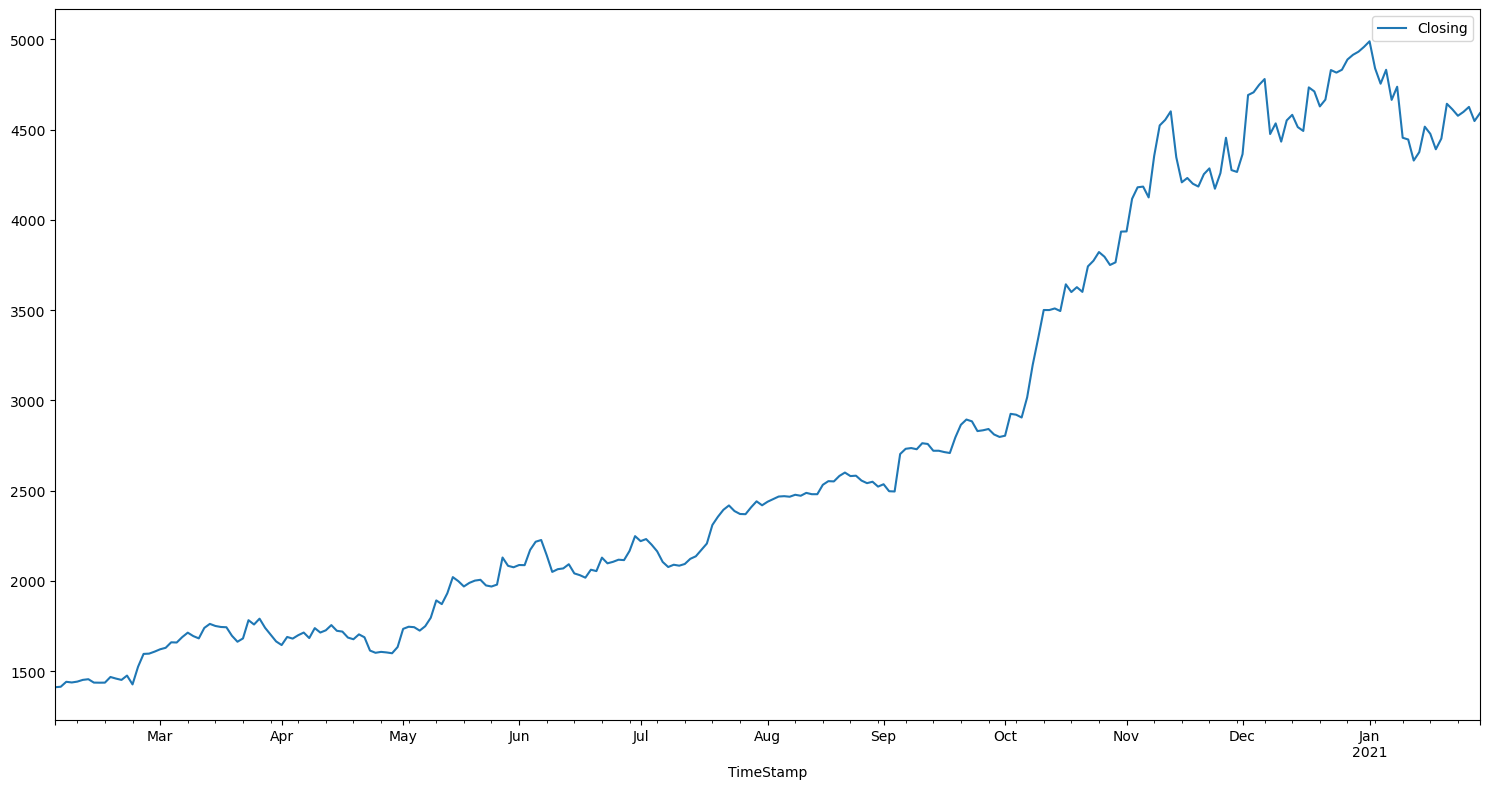

In [ ]:
from pylab import rcParams
rcParams['figure.figsize'] = 15,8
df.plot()

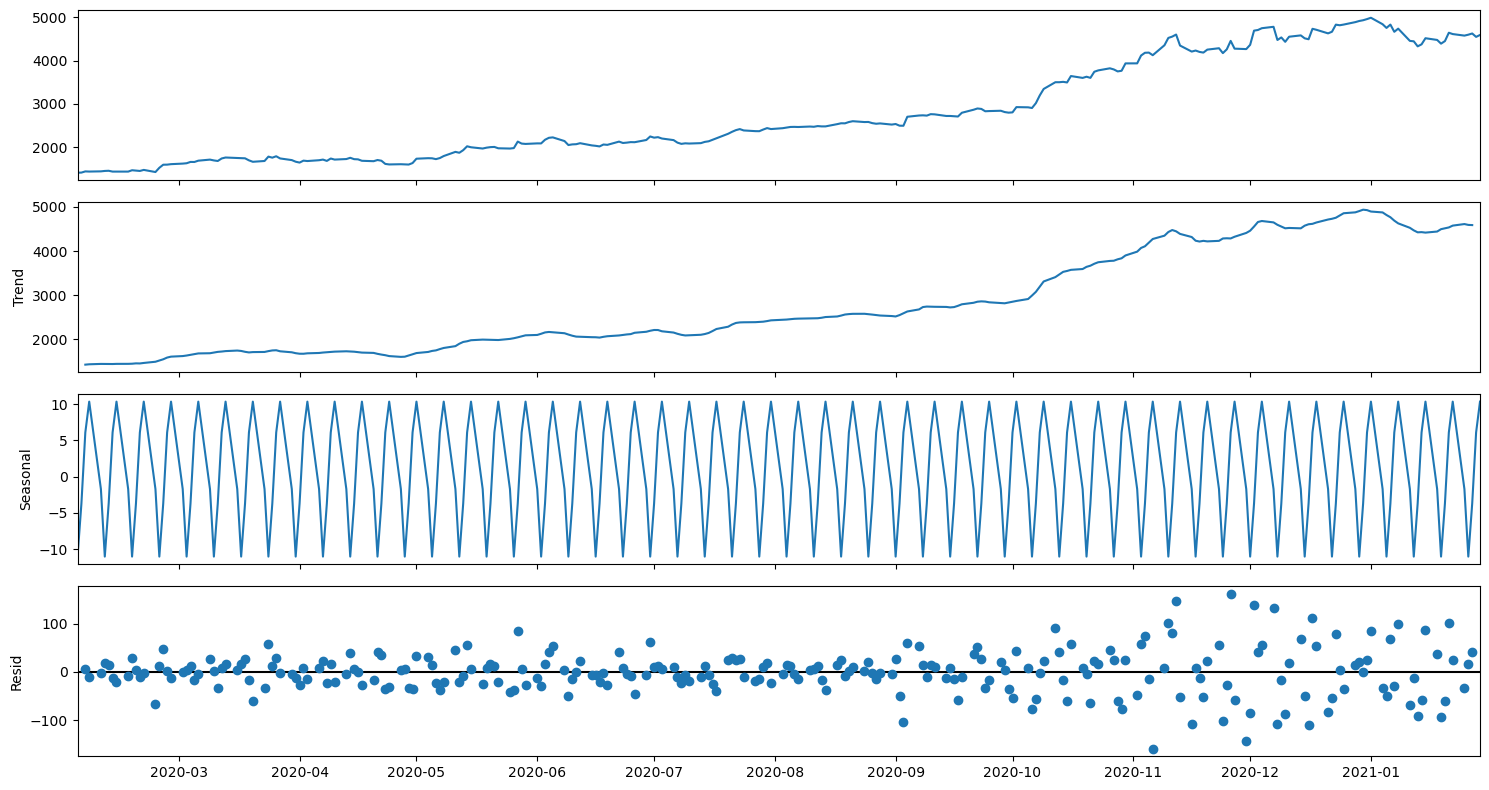

In [ ]:
from statsmodels.tsa.seasonal import  seasonal_decompose
decomposition = seasonal_decompose(df,model='additive')
decomposition.plot();

In [ ]:
#tester le comportement stationnaire des séries
from statsmodels.tsa.stattools  import  adfuller
observations= df.values
test_result = adfuller(observations)
test_result

(np.float64(-0.007528997627653994),
 np.float64(0.9579049966158176),
 0,
 258,
 {'1%': np.float64(-3.455952927706342),
  '5%': np.float64(-2.8728086526320302),
  '10%': np.float64(-2.572774990685656)},
 np.float64(2770.616012349057))

In [ ]:
####La série est non stationnaire car la valeur p est élevée. L'application de la différenciation du premier ordre
df_diff = df.diff(periods=1).dropna()
observations= df_diff.values
test_result = adfuller(observations)
test_result

(np.float64(-15.39490882357454),
 np.float64(3.2726341074582285e-28),
 0,
 257,
 {'1%': np.float64(-3.4560535712549925),
  '5%': np.float64(-2.8728527662442334),
  '10%': np.float64(-2.5727985212493754)},
 np.float64(2759.816026154356))